Pipeline template

Notebook to illustrate the overall pipeline flow including:

- reading in data
- adding non signal noise
- modifying record to be input ready
- inputting to DMD
- converting recovered outputs to comparable outputs
- examining recovery metrics

## Preamble

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
from matplotlib.colors import BoundaryNorm


# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *
from src.msc_thesis.synFigures import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Application
['/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/msc_thesis/lib/python311.zip', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/lib-dynload', '', '/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages', '/home/elliott/projects/msc_thesis_project']
['/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/projects/msc_thesis_project', '/home/elliott/miniforge3/envs/m

## Reading in global data

## Running pipeline (loading data, run DMD, recover modes)

In [68]:
# defining test parameters

nmax = 9
svd_rank = 0.9999

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":8,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":False,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

# defining same base set
# defining modes used
base_set_mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
base_set_mode_numbers = [str(mode_number) for mode_number in base_set_mode_numbers]




In [69]:
# code to make heatmap - add into heatmap plotter at some point
candidate_mode_numbers = ["6", "32", "48"] # full = ["1", "32", "48"]

guest_type_list = ["disparate", "closest"]
guest_perturb_list = [-50, -40, -30, -20, -10, -5, 5, 10, 20, 30, 40, 50]
background_type_list = ["pair", "base_set"]

targeted_test_results_total = {}


In [70]:
%%capture
# for each svd rank to be tested
for background_type in background_type_list:

    targeted_test_results = {}

    for cand_mode_num in candidate_mode_numbers:

        targeted_test_results[cand_mode_num] = {}

        for guest_type in guest_type_list:

            targeted_test_results[cand_mode_num][guest_type] = {}

            for perturbation in guest_perturb_list:

                targeted_test_results[cand_mode_num][guest_type][perturbation] = {}

                guest_number = f"g{cand_mode_num}_{guest_type}_T{perturbation}"

                if background_type == "base_set":
                    mode_numbers = base_set_mode_numbers.copy()
                    mode_numbers.append(guest_number)
                elif background_type == "pair":
                    mode_numbers = [cand_mode_num, guest_number]

                print(guest_number)

                # getting full (nmax=15) unperturbed records and synthetic suite info
                record_dict, syn_suite_info = Record_Dict_Construct(mode_numbers=mode_numbers, nmax=nmax)

                print(syn_suite_info[cand_mode_num]["true_period"])
                print(syn_suite_info[guest_number]["true_period"])
                

                # getting output of dmd for a run with a specific nmax, svd rank
                results_dict = Pipeline_Run(record_dict, syn_suite_info, 
                        dmd_settings, nmax=nmax, svd_rank=svd_rank,
                        ensemble_settings=ensemble_settings)

                # check resolved results
                resolved_results = results_dict["resolved"]

                candidate_results = resolved_results[cand_mode_num]
                
                if candidate_results:

                    candidate_period = candidate_results["match_period"]

                    guest_results = resolved_results[guest_number]

                    if guest_results:

                        guest_period = guest_results["match_period"]

                        if guest_period == candidate_period:
                            candidate_recovery = {
                                "period":candidate_period,
                                "similarity":candidate_results["match_similarity"],
                                "period_error":candidate_results["match_period_error"],
                                "guest_state":"merged"
                            }
                        else:
                            candidate_recovery = {
                                "period":candidate_period,
                                "similarity":candidate_results["match_similarity"],
                                "period_error":candidate_results["match_period_error"],
                                "guest_state":"separate"
                            }

                    else:
                        
                        candidate_recovery = {
                            "period":candidate_period,
                            "similarity":candidate_results["match_similarity"],
                            "period_error":candidate_results["match_period_error"],
                            "guest_state":"unmatched"
                        }
                else:
                    candidate_recovery = False

                targeted_test_results[cand_mode_num][guest_type][perturbation] = candidate_recovery

    targeted_test_results_total[background_type] = targeted_test_results



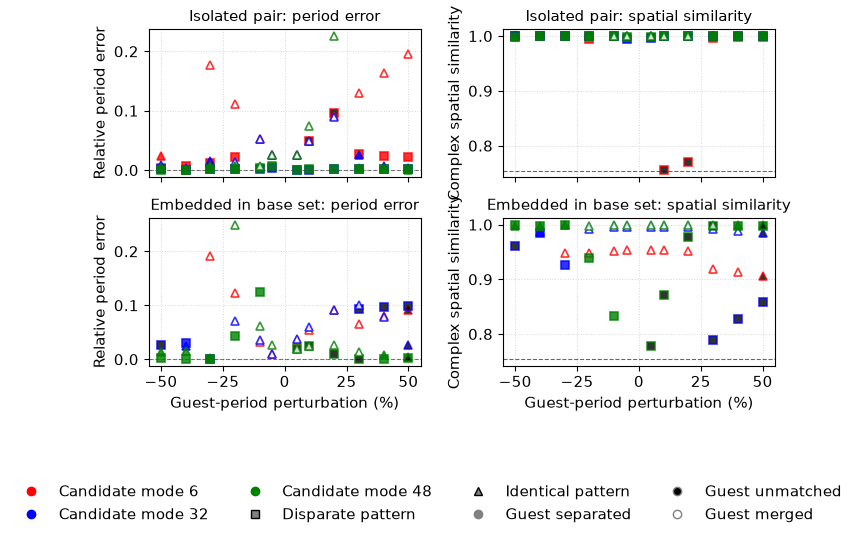

In [71]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 11,
    "axes.labelsize": 11,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

fig, axes = plt.subplots(
    ncols=2,
    nrows=2,
    figsize=(text_width, 0.75 * text_width),
    sharex=True,
    constrained_layout=False,
)

candidate_colours = {
    "6": "red",
    "32": "blue",
    "48": "green",
}

guest_marker = {
    "disparate": "s",  # square
    "closest": "^",    # triangle
}

background_labels = {
    "pair": "Isolated pair",
    "base_set": "Embedded in base set",
}


def get_marker_facecolour(guest_state, candidate_colour):
    """Return marker infill corresponding to guest recovery state."""

    if guest_state in {"separate", "separated"}:
        return candidate_colour
    elif guest_state == "unmatched":
        return "black"
    elif guest_state == "merged":
        return "white"
    else:
        raise ValueError(f"Unknown guest state: {guest_state}")


for i, background_type in enumerate(background_type_list):

    targeted_test_results = targeted_test_results_total[background_type]

    for cand_mode_num in candidate_mode_numbers:

        cand_results = targeted_test_results[cand_mode_num]
        candidate_colour = candidate_colours[cand_mode_num]

        for guest_type in guest_type_list:

            cand_guest_results = cand_results[guest_type]
            marker = guest_marker[guest_type]

            for perturbation in guest_perturb_list:

                candidate_recovery = cand_guest_results[perturbation]

                if candidate_recovery:

                    guest_state = candidate_recovery["guest_state"]
                    period_error = candidate_recovery["period_error"]
                    similarity = candidate_recovery["similarity"]

                    facecolour = get_marker_facecolour(
                        guest_state,
                        candidate_colour,
                    )

                    common_plot_kwargs = {
                        "marker": marker,
                        "linestyle": "none",
                        "markersize": 6,
                        "markeredgecolor": candidate_colour,
                        "markeredgewidth": 1.2,
                        "markerfacecolor": facecolour,
                        "alpha": 0.8,
                    }

                    axes[i, 0].plot(
                        int(perturbation),
                        period_error,
                        **common_plot_kwargs,
                    )

                    axes[i, 1].plot(
                        int(perturbation),
                        similarity,
                        **common_plot_kwargs,
                    )

    row_label = background_labels.get(
        background_type,
        str(background_type).replace("_", " ").title(),
    )

    axes[i, 0].set_title(f"{row_label}: period error")
    axes[i, 1].set_title(f"{row_label}: spatial similarity")

    axes[i, 0].set_ylabel("Relative period error")
    axes[i, 1].set_ylabel("Complex spatial similarity")

    for ax in axes[i, :]:
        ax.grid(
            True,
            linestyle=":",
            linewidth=0.7,
            alpha=0.5,
        )


# Labels along the bottom row
for ax in axes[-1, :]:
    ax.set_xlabel("Guest-period perturbation (%)")


# Optional reference lines
for ax in axes[:, 0]:
    ax.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--",
        alpha=0.6,
        zorder=0,
    )

for ax in axes[:, 1]:
    ax.axhline(
        similarity_thresholds["full_match"][str(nmax)],
        color="black",
        linewidth=0.8,
        linestyle="--",
        alpha=0.6,
        zorder=0,
    )


# ------------------------------------------------------------------
# Shared legend below all subplots
# ------------------------------------------------------------------

candidate_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markersize=6,
        markerfacecolor=colour,
        markeredgecolor=colour,
        label=f"Candidate mode {mode_num}",
    )
    for mode_num, colour in candidate_colours.items()
]

guest_type_handles = [
    Line2D(
        [],
        [],
        marker="s",
        linestyle="none",
        markersize=6,
        markerfacecolor="grey",
        markeredgecolor="black",
        label="Disparate pattern",
    ),
    Line2D(
        [],
        [],
        marker="^",
        linestyle="none",
        markersize=6,
        markerfacecolor="grey",
        markeredgecolor="black",
        label="Identical pattern",
    ),
]

guest_state_handles = [
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markersize=6,
        markerfacecolor="grey",
        markeredgecolor="grey",
        label="Guest separated",
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markersize=6,
        markerfacecolor="black",
        markeredgecolor="grey",
        label="Guest unmatched",
    ),
    Line2D(
        [],
        [],
        marker="o",
        linestyle="none",
        markersize=6,
        markerfacecolor="white",
        markeredgecolor="grey",
        label="Guest merged",
    ),
]

fig.legend(
    handles=(
        candidate_handles
        + guest_type_handles
        + guest_state_handles
    ),
    loc="lower center",
    bbox_to_anchor=(0.5, 0.0),
    ncol=4,
    frameon=False,
)

# Leave space at the bottom for the shared legend
fig.tight_layout(rect=(0, 0.20, 1, 1))

plt.show()

In [72]:
import numpy as np
import pandas as pd


def closest_positive_negative(perturbations):
    """
    Return the successful perturbations closest to zero on each side.

    For example:
        [-20, -10, -5, 2, 10] -> (-5, 2)
    """
    perturbations = np.asarray(perturbations, dtype=float)

    negative = perturbations[perturbations < 0]
    positive = perturbations[perturbations > 0]

    closest_negative = np.max(negative) if negative.size else np.nan
    closest_positive = np.min(positive) if positive.size else np.nan

    return closest_negative, closest_positive


def targeted_period_resolution_table(
    targeted_test_results_total,
    candidate_mode_numbers,
    disparate_key="disparate",
    same_phasor_key="closest",
):
    """
    Summarise targeted period-resolution results.

    Disparate case:
        Find the closest positive and negative perturbations for which
        the candidate mode is recovered, regardless of guest recovery.

    Same-phasor case:
        Find the closest positive and negative perturbations for which
        candidate and guest are recovered separately
        (guest_state == "separate").

    Returns
    -------
    pandas.DataFrame
    """

    background_labels = {
        "pair": "Isolated",
        "base_set": "Embedded",
    }

    table_rows = []

    for background_type, background_results in (
        targeted_test_results_total.items()
    ):
        for cand_mode_num in candidate_mode_numbers:

            candidate_results = background_results[cand_mode_num]

            # -----------------------------------------------------
            # Disparate spatial-pattern case
            # Candidate only needs to be recovered
            # -----------------------------------------------------
            disparate_results = candidate_results[disparate_key]

            disparate_successes = [
                float(perturbation)
                for perturbation, result in disparate_results.items()
                if result
            ]

            disparate_negative, disparate_positive = (
                closest_positive_negative(disparate_successes)
            )

            # -----------------------------------------------------
            # Same spatial-pattern case
            # Candidate and guest must be distinct recovered modes
            # -----------------------------------------------------
            same_results = candidate_results[same_phasor_key]

            same_separated = [
                float(perturbation)
                for perturbation, result in same_results.items()
                if (
                    result
                    and result.get("guest_state") == "separate"
                )
            ]

            same_negative, same_positive = (
                closest_positive_negative(same_separated)
            )

            table_rows.append({
                "Record": background_labels.get(
                    background_type,
                    background_type,
                ),
                "Candidate mode": cand_mode_num,
                "Disparate − threshold (%)": disparate_negative,
                "Disparate + threshold (%)": disparate_positive,
                "Same phasor − threshold (%)": same_negative,
                "Same phasor + threshold (%)": same_positive,
            })

    summary_table = pd.DataFrame(table_rows)

    # Keep the intended record ordering
    record_order = ["Isolated", "Embedded"]
    summary_table["Record"] = pd.Categorical(
        summary_table["Record"],
        categories=record_order,
        ordered=True,
    )

    summary_table = (
        summary_table
        .sort_values(["Record", "Candidate mode"])
        .reset_index(drop=True)
    )

    return summary_table

In [73]:
resolution_table = targeted_period_resolution_table(
    targeted_test_results_total,
    candidate_mode_numbers,
)

display(resolution_table)

,Record,Candidate mode,Disparate − threshold (%),Disparate + threshold (%),Same phasor − threshold (%),Same phasor + threshold (%)
0,Isolated,32,-5.0,5.0,-30.0,30.0
1,Isolated,48,-5.0,5.0,-20.0,30.0
2,Isolated,6,-20.0,10.0,-50.0,NaN
3,Embedded,32,-30.0,30.0,-40.0,NaN
4,Embedded,48,-10.0,5.0,-30.0,40.0
5,Embedded,6,NaN,NaN,NaN,NaN


# Results_dict

Results dict is a dictionary containing the results for a single run of DMD.

It is split into 4 kinds of records [record_key]:

- "ideal"
- "resolved"
- "background"
- "ensemble" = ["1", "2", ..., "n_ensemble"]

If a record converged/ obtained modes (i.e. opDMD LS convergence), a result is returned (see below), False if not.

each 'record' result data set stores the following for each mode [record_key]["mode_key"]:

- whether match was made (see below) or not (will be False)
- "match_period" = what is the period of the DMD mode matched
- "period_error" = waht is the fractional error in period to matched mode
- "similarity" = similarity of complex phasor recovered vs true input

as well as the overall modes recovered for that run [record_key]["match_count"]

In [ ]:
# heatmap
%%capture

# nmax values to test
nmax_list = np.arange(5, 16, 2)

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

# code to make heatmap - add into heatmap plotter at some point
match_count_heatmap = np.zeros((len(nmax_list), len(svd_rank_list)))

# for each nmax to be tested
for n_idx, nmax in enumerate(nmax_list):

    # for each svd rank to be tested
    for r_idx, svd_rank in enumerate(svd_rank_list):
        
        # getting output of dmd for a run with a specific nmax, svd rank
        results_dict = Pipeline_Run(record_dict_global, syn_suite_info_global, 
             dmd_settings, nmax=nmax, svd_rank=svd_rank,
             ensemble_settings=ensemble_settings)

        results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)
    
        print(results_dict.keys())

        n_r_match_count = results_dict["median"]["match_count"]["value"]
        # getting p95 to p05 difference
        n_r_match_spread = results_dict["median"]["match_count"]["p95"] - \
                        results_dict["median"]["match_count"]["p05"]
        
        match_count_heatmap[n_idx, r_idx] = n_r_match_count

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.774419332900512e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.687448318386771e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 2.637346614158442e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/projects/msc_thesis_project/src/msc_thesis/synDMD.py:630: RuntimeWarning: divide by zero encountered in scalar divide
  periods = [2.0 * np.pi / np.abs(eig.imag) for eig in continuous_eigenvalue

dict_keys(['ideal', 'resolved', 'background', 'ensemble', 'median'])


ensembles: 100%|██████████| 10/10 [00:00<00:00, 22.66it/s]


dict_keys(['ideal', 'resolved', 'background', 'ensemble', 'median'])


ensembles: 100%|██████████| 10/10 [00:00<00:00, 16.67it/s]


...

dict_keys(['ideal', 'resolved', 'background', 'ensemble', 'median'])


ensembles: 100%|██████████| 10/10 [00:00<00:00, 11.55it/s]


dict_keys(['ideal', 'resolved', 'background', 'ensemble', 'median'])


ensembles: 100%|██████████| 10/10 [00:01<00:00,  8.95it/s]

dict_keys(['ideal', 'resolved', 'background', 'ensemble', 'median'])


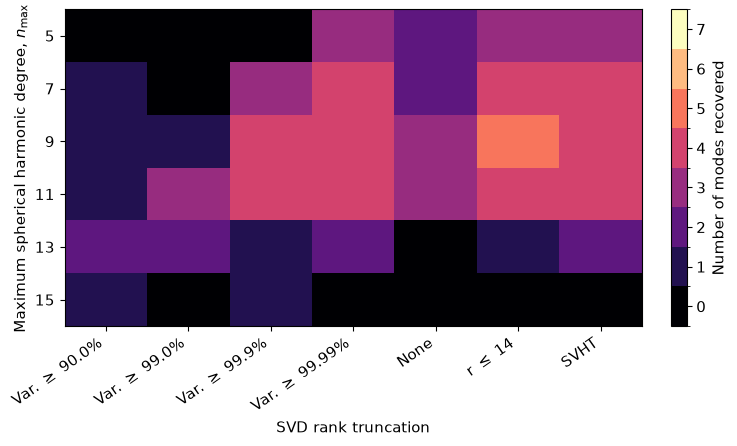

In [13]:
heatmap_figure, heatmap_axis, heatmap_colourbar = (
    Plot_Match_Count_Heatmap(
        match_count_heatmap,
        nmax_list,
        svd_rank_labels,
        n_modes=len(mode_numbers),
        figure_width=text_width,
    )
)
plt.show()

In [60]:
# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":20,
    "record_for_ensemble":"resolved"
}

nmax_choice = 9
svd_rank_choice = 0.9999

# getting output of dmd for a run with a specific nmax, svd rank
results_dict = Pipeline_Run(record_dict_global, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)


ensembles: 100%|██████████| 20/20 [00:02<00:00,  8.37it/s]


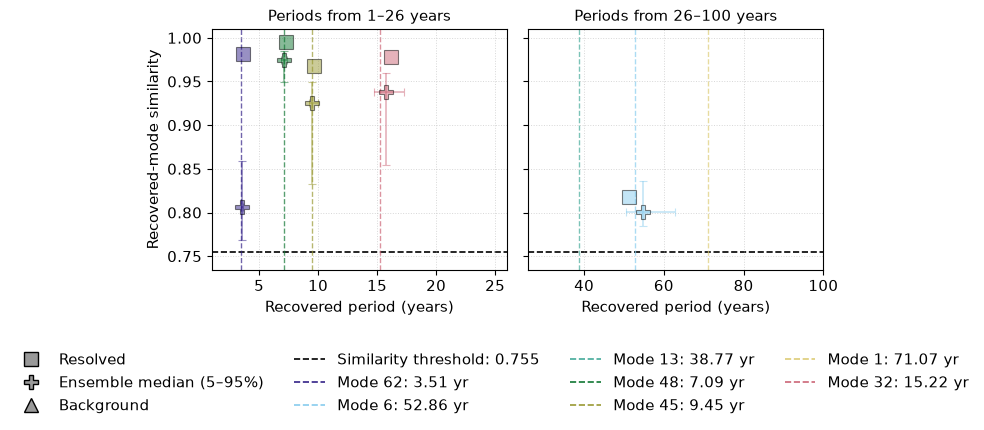

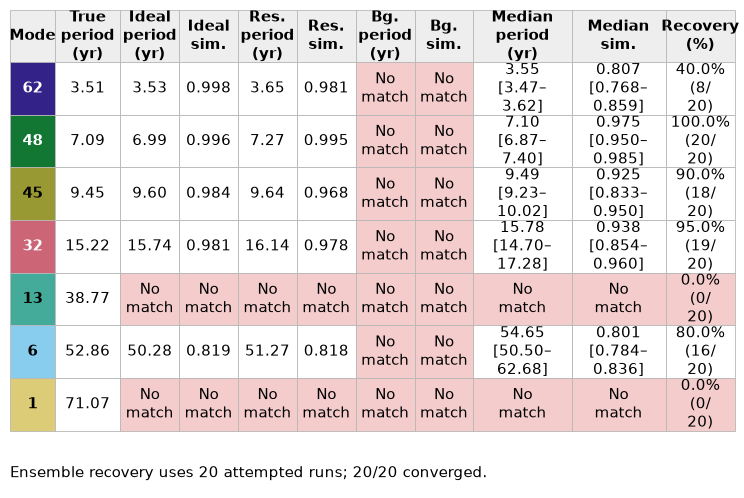

In [61]:
similarity_threshold = similarity_thresholds[
    "full_match"
][str(nmax_choice)]

records_to_include = ["ideal","resolved","background","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, syn_suite_info_global, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, syn_suite_info_global,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

In [54]:
%%capture

nmax_choice = 9
svd_rank_choice = 0.9999

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":False,
    "embedding_d":0,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":30,
    "record_for_ensemble":"resolved"
}

hankel_d_list = [0, 2, 4, 6, 8, 10]


# code to make heatmap - add into heatmap plotter at some point
d_match_results = {
    "median": np.zeros(len(hankel_d_list)),
    "p95": np.zeros(len(hankel_d_list)),
    "p05": np.zeros(len(hankel_d_list)),
} 

# for each embedding d to be tested
for d_idx, embedding_d in enumerate(hankel_d_list):

    if embedding_d > 0:
        dmd_settings["hankel_flag"] = True
        dmd_settings["embedding_d"] = embedding_d


    # getting output of dmd for a run with a specific nmax, svd rank
    results_dict = Pipeline_Run(record_dict_global, syn_suite_info_global, 
            dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
            ensemble_settings=ensemble_settings)

    results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

    d_match_results["median"][d_idx] = results_dict["median"]["match_count"]["value"]
    d_match_results["p95"][d_idx] = results_dict["median"]["match_count"]["p95"]
    d_match_results["p05"][d_idx] = results_dict["median"]["match_count"]["p05"]

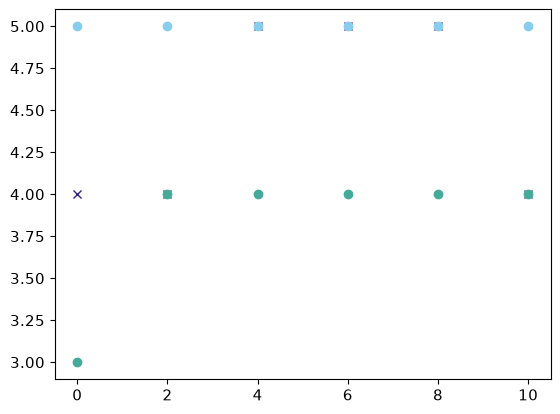

In [55]:
plt.plot(hankel_d_list, d_match_results["median"], 'x')
plt.plot(hankel_d_list, d_match_results["p95"], 'o')
plt.plot(hankel_d_list, d_match_results["p05"], 'o')

In [62]:
# specific exact case

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":8,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":20,
    "record_for_ensemble":"resolved"
}

nmax_choice = 9
svd_rank_choice = 0.9999

# getting output of dmd for a run with a specific nmax, svd rank
results_dict = Pipeline_Run(record_dict_global, syn_suite_info_global, 
        dmd_settings, nmax=nmax_choice, svd_rank=svd_rank_choice,
        ensemble_settings=ensemble_settings)


results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)

/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 1.5675629387077968e+16. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(


/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 954255.2646203779. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
/home/elliott/miniforge3/envs/msc_thesis/lib/python3.11/site-packages/pydmd/snapshots.py:73: UserWarning: Input data condition number 126728.38329364965. Consider preprocessing data, passing in augmented data
matrix, or regularization methods.
  warnings.warn(
ensembles: 100%|██████████| 20/20 [00:06<00:00,  3.10it/s]


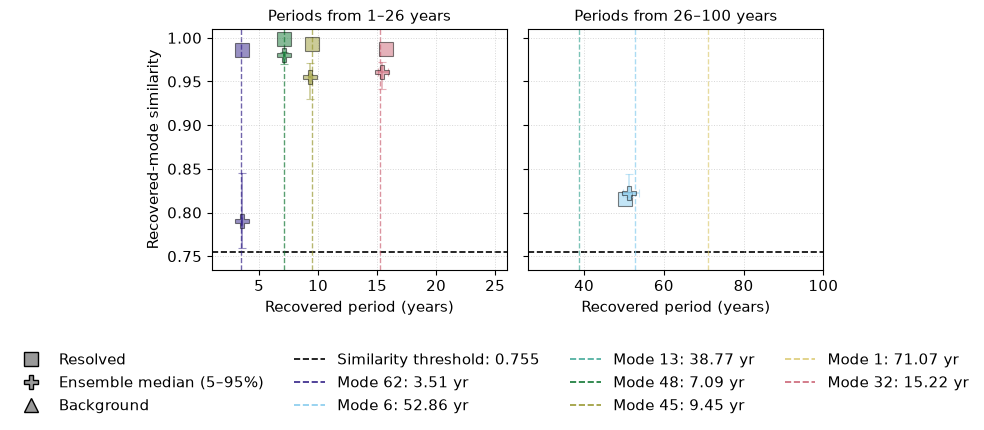

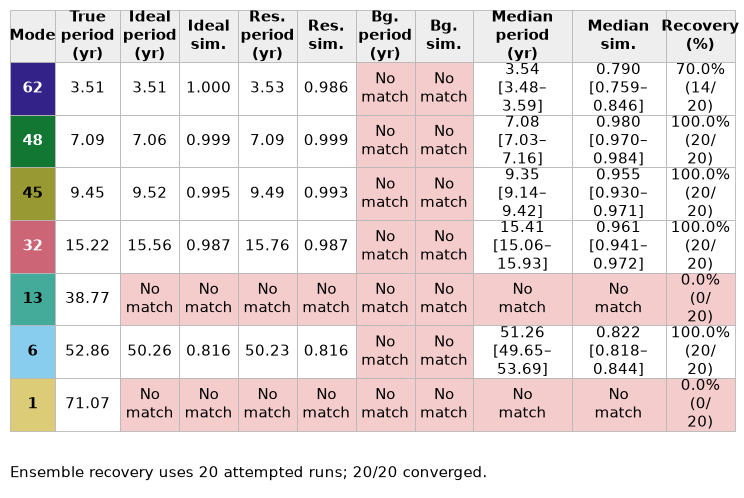

In [63]:
similarity_threshold = similarity_thresholds[
    "full_match"
][str(nmax_choice)]

records_to_include = ["ideal","resolved","background","median"]

similarity_figure, similarity_axes = Plot_Period_Similarity_Results(
    results_dict, syn_suite_info_global, similarity_threshold,
    record_markers, record_plotting_params, figure_width=text_width,
)

summary_figure, summary_table = Results_Summary_Table(results_dict, syn_suite_info_global,
    records_to_include=records_to_include, ensemble_percentage_basis="attempted",
)
plt.show()

In [64]:
%%capture

# nmax values to test
nmax_list = np.arange(5, 16, 2)

# svd rank values to test
svd_rank_list = [0.9, 0.99, 0.999, 0.9999, -1, 2*len(mode_numbers), 0]
svd_rank_labels = Make_SVD_Labels(svd_rank_list)

dmd_settings = {
    "dmd_type":"exact",
    "hankel_flag":True,
    "embedding_d":4,
    "weight_flag":True
}

# uncertainty ensemble toggle
ensemble_settings = {
    "ensemble_flag":True,
    "n_ensemble":10,
    "record_for_ensemble":"resolved"
}

# code to make heatmap - add into heatmap plotter at some point
match_count_heatmap = np.zeros((len(nmax_list), len(svd_rank_list)))

# for each nmax to be tested
for n_idx, nmax in enumerate(nmax_list):

    # for each svd rank to be tested
    for r_idx, svd_rank in enumerate(svd_rank_list):
        
        # getting output of dmd for a run with a specific nmax, svd rank
        results_dict = Pipeline_Run(record_dict_global, syn_suite_info_global, 
             dmd_settings, nmax=nmax, svd_rank=svd_rank,
             ensemble_settings=ensemble_settings)

        results_dict = Ensemble_To_Median(results_dict, syn_suite_info_global)
    
        print(results_dict.keys())

        n_r_match_count = results_dict["median"]["match_count"]["value"]
        # getting p95 to p05 difference
        n_r_match_spread = results_dict["median"]["match_count"]["p95"] - \
                        results_dict["median"]["match_count"]["p05"]
        
        match_count_heatmap[n_idx, r_idx] = n_r_match_count

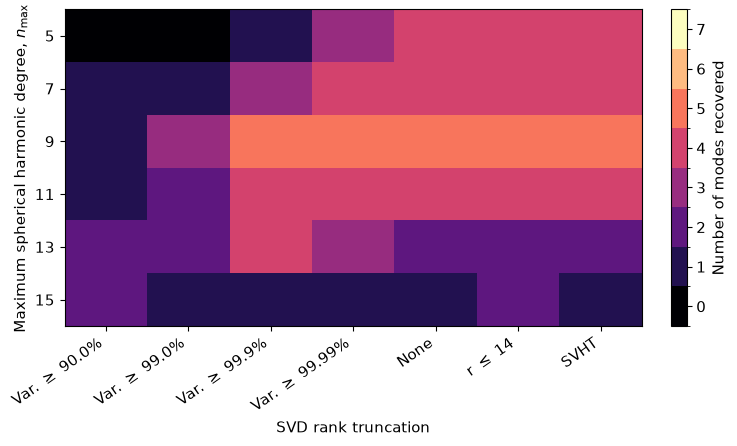

In [65]:
heatmap_figure, heatmap_axis, heatmap_colourbar = (
    Plot_Match_Count_Heatmap(
        match_count_heatmap,
        nmax_list,
        svd_rank_labels,
        n_modes=len(mode_numbers),
        figure_width=text_width,
    )
)
plt.show()